# Setup & connection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from pathlib import Path
from dotenv import load_dotenv

# .env lives in ingestion/, not notebooks/, so point to it explicitly
load_dotenv(dotenv_path=Path("../ingestion/.env"))

db_url = os.getenv("DATABASE_URL")
if db_url is None:
    raise RuntimeError("DATABASE_URL not found — check the .env path above matches your folder structure")

print("Connected to:", db_url.split("@")[-1])  # prints host/db only, not credentials

engine = create_engine(db_url)

sns.set_style("darkgrid")
pd.set_option("display.max_columns", None)

Connected to: hayabusa.proxy.rlwy.net:22373/railway


# Load raw tables

In [3]:
flights = pd.read_sql("SELECT * FROM flights", engine)
airports = pd.read_sql("SELECT * FROM airports", engine)
weather = pd.read_sql("SELECT * FROM weather_snapshots", engine)

print(f"Flights: {flights.shape}")
print(f"Airports: {airports.shape}")
print(f"Weather: {weather.shape}")

Flights: (600, 13)
Airports: (99, 7)
Weather: (17, 9)


## Known data characteristics

- **Codeshare duplication**: AviationStack returns each codeshare as a
  separate flight record, even when multiple flight numbers refer to the
  same physical flight (identical scheduled/actual times). We de-duplicate
  below before computing delay statistics.
- **Airport enrichment**: as of this data pull, most airports are stub rows
  (code only). Enrichment is a separate planned task.

# De-duplicate codeshares into physical flights

In [4]:
# Group by the fields that identify a *physical* flight rather than a
# marketing flight number, so codeshares collapse into one row.
physical_flights = (
    flights
    .sort_values("flight_number")
    .groupby(["scheduled_departure", "actual_departure", "origin", "destination"], dropna=False)
    .agg(
        flight_numbers=("flight_number", lambda x: ", ".join(x)),
        num_codeshares=("flight_number", "count"),
        airline_primary=("airline", "first"),
        scheduled_arrival=("scheduled_arrival", "first"),
        actual_arrival=("actual_arrival", "first"),
        status=("status", "first"),
        delay_minutes=("delay_minutes", "first"),
        aircraft_registration=("aircraft_registration", "first"),
    )
    .reset_index()
)

print(f"Raw flight records: {len(flights)}")
print(f"Physical flights (de-duplicated): {len(physical_flights)}")
print(f"Records with codeshares: {(physical_flights['num_codeshares'] > 1).sum()}")

Raw flight records: 600
Physical flights (de-duplicated): 193
Records with codeshares: 78


# Missing data overview

In [5]:
missing = flights.isnull().sum().to_frame("null_count")
missing["pct"] = (missing["null_count"] / len(flights) * 100).round(1)
missing

,null_count,pct
id,0,0.0
flight_number,0,0.0
airline,0,0.0
origin,0,0.0
destination,0,0.0
scheduled_departure,0,0.0
actual_departure,570,95.0
scheduled_arrival,0,0.0
actual_arrival,600,100.0
aircraft_registration,600,100.0


# Status breakdown

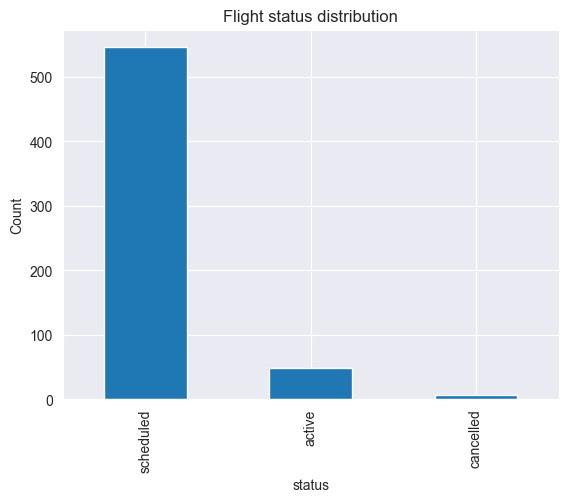

In [6]:
flights["status"].value_counts().plot(kind="bar", title="Flight status distribution")
plt.ylabel("Count")
plt.show()

# Delay distribution (on de-duplicated data)

In [7]:
delayed = physical_flights.dropna(subset=["delay_minutes"])
print(f"Physical flights with a delay value: {len(delayed)}")

if len(delayed) > 0:
    delayed["delay_minutes"].describe()

Physical flights with a delay value: 5


In [8]:
if len(delayed) > 5:  # only worth plotting once you have more data
    plt.figure(figsize=(8, 5))
    sns.histplot(delayed["delay_minutes"], bins=20, kde=True)
    plt.title("Delay distribution (minutes)")
    plt.xlabel("Delay (minutes)")
    plt.show()
else:
    print("Not enough delay data yet for a meaningful distribution — revisit after a few more days of ingestion.")

Not enough delay data yet for a meaningful distribution — revisit after a few more days of ingestion.


# Time coverage check

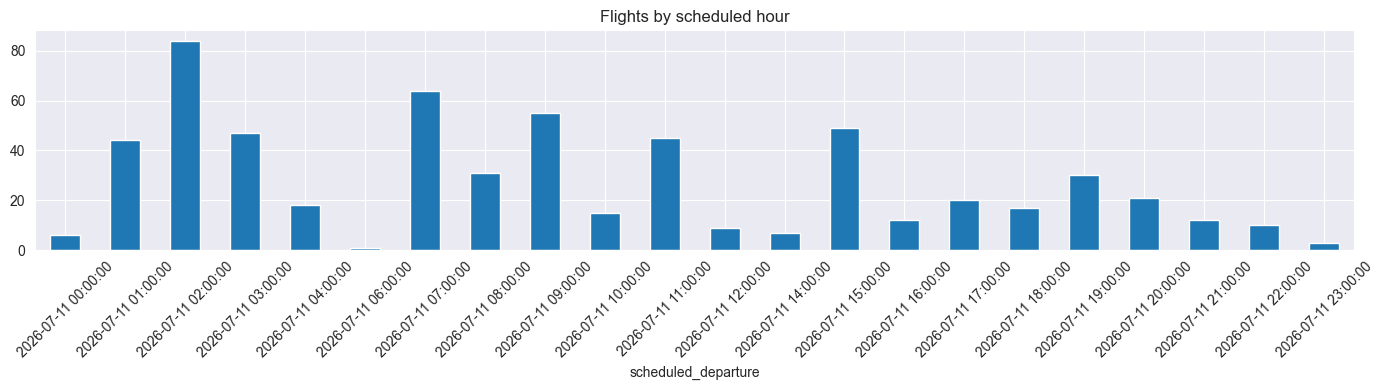

In [13]:
flights["scheduled_departure"] = pd.to_datetime(flights["scheduled_departure"])
hourly_counts = flights.groupby(flights["scheduled_departure"].dt.floor("h")).size()
hourly_counts.index = hourly_counts.index.astype(str)

hourly_counts.plot(kind="bar", figsize=(14, 4), title="Flights by scheduled hour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Airport enrichment status

In [10]:
total = len(airports)
enriched = airports.dropna(subset=["name", "latitude"]).shape[0]

print(f"Airports: {total}")
print(f"Enriched: {enriched} ({enriched/total*100:.1f}%)")
print(f"Stub rows: {total - enriched}")

Airports: 99
Enriched: 1 (1.0%)
Stub rows: 98


# Weather coverage sanity check

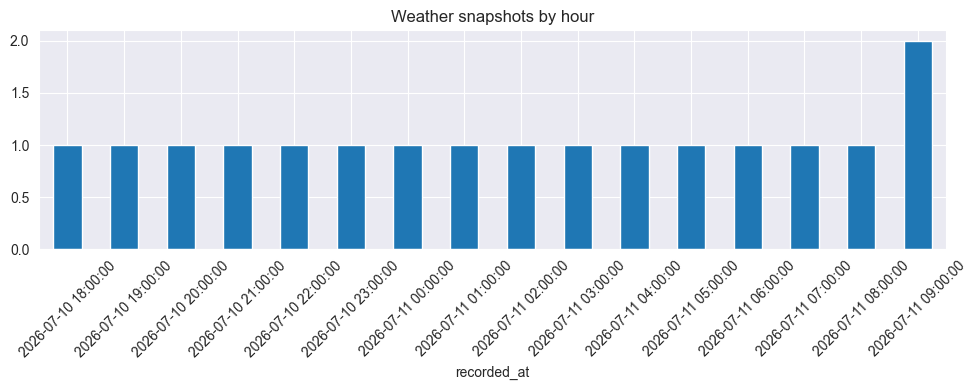

In [12]:
weather["recorded_at"] = pd.to_datetime(weather["recorded_at"])
weather_hourly = weather.groupby(weather["recorded_at"].dt.floor("h")).size()
weather_hourly.index = weather_hourly.index.astype(str)  # avoid PeriodIndex inference issue

weather_hourly.plot(kind="bar", figsize=(10, 4), title="Weather snapshots by hour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary markdown (fill in after running)

## Summary of findings

- Total raw flight records: ___
- Physical flights after de-duplication: ___
- % records with codeshares: ___
- Delay data currently available for ___ physical flights (expected to grow as flights complete)
- Airport enrichment: ___ / 82 enriched
- Next step: revisit this notebook after several more days of accumulated data before drawing conclusions on delay patterns